In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import  scipy
from scipy.stats.mstats import winsorize
from sklearn.model_selection import train_test_split

ModuleNotFoundError: No module named 'pandas'

In [ ]:

product_df = pd.read_csv(
   "/content/ProductLevel.csv",
    encoding="latin1"
)


In [ ]:
print(f"Product Dataset:  {product_df.shape}")


Product Dataset:  (866, 25)


In [ ]:
product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 866 entries, 0 to 865
Data columns (total 25 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   *PCF-ID                                    866 non-null    object 
 1   Year of reporting                          866 non-null    int64  
 2   *Stage-level CO2e available                866 non-null    object 
 3   Product name (and functional unit)         866 non-null    object 
 4   Product detail                             856 non-null    object 
 5   Company                                    866 non-null    object 
 6   Country (where company is incorporated)    866 non-null    object 
 7   Company's GICS Industry Group              866 non-null    object 
 8   Company's GICS Industry                    866 non-null    object 
 9   *Company's sector                          866 non-null    object 
 10  Product weight (kg)       

In [ ]:



product_data_summary = pd.DataFrame({
    'Source_Table': 'product_df',
    'Column_Name': product_df.columns,
    'Non_Null_Count': product_df.notnull().sum().values,
    'Unique_Values': product_df.nunique().values,
    'Data_Type': product_df.dtypes.values
})







display(product_data_summary)

,Source_Table,Column_Name,Non_Null_Count,Unique_Values,Data_Type
0,product_df,*PCF-ID,866,866,object
1,product_df,Year of reporting,866,5,int64
2,product_df,*Stage-level CO2e available,866,2,object
3,product_df,Product name (and functional unit),866,672,object
4,product_df,Product detail,856,496,object
5,product_df,Company,866,145,object
6,product_df,Country (where company is incorporated),866,28,object
7,product_df,Company's GICS Industry Group,866,30,object
8,product_df,Company's GICS Industry,866,35,object
9,product_df,*Company's sector,866,8,object


In [ ]:
product_df['Year of reporting'].value_counts().sort_index()

,count
Year of reporting,
2013,179
2014,190
2015,217
2016,218
2017,62


Year was retained as a numerical feature because it represents an ordered temporal variable. Preserving its integer values allows machine learning algorithms to learn potential temporal trends without introducing unnecessary feature transformations.

In [ ]:
product_df['*Stage-level CO2e available'].value_counts()

,count
*Stage-level CO2e available,
No,445
Yes,421


In [ ]:
product_df['Country (where company is incorporated)'].value_counts()

,count
Country (where company is incorporated),
USA,305
Japan,110
Germany,67
Taiwan,60
Netherlands,35
Finland,35
United Kingdom,32
Switzerland,28
Sweden,26


### Drop replace by Region

In [ ]:
product_df["Company's GICS Industry Group"].value_counts()

,count
Company's GICS Industry Group,
Technology Hardware & Equipment,195
Materials,161
"Food, Beverage & Tobacco",101
Automobiles & Components,73
Consumer Durables & Apparel,52
Commercial & Professional Services,42
Capital Goods,33
Chemicals,29
Software & Services,27


In [ ]:
product_df["Company's GICS Industry"].value_counts()

,count
Company's GICS Industry,
Not used for 2015 reporting,215
Chemicals,82
Computers & Peripherals,70
Beverages,70
"Electronic Equipment, Instruments & Components",47
Commercial Services & Supplies,42
Auto Components,38
Paper & Forest Products,34
"Textiles, Apparel & Luxury Goods",31


"Provides reliable granular industry classification (30 well-defined groups) without structural missingness. Captures mid-level manufacturing and operational carbon baselines."

In [ ]:
product_df["*Company's sector"].value_counts()

,count
*Company's sector,
"Computer, IT & telecom",253
Food & Beverage,139
"Home durables, textiles, & equipment",122
Chemicals,116
Automobiles & components,75
Construction & commercial materials,67
Comm. equipm. & capital goods,56
Packaging for consumer goods,38


Highly dense, zero-missingness high-level economic categorization (8 primary sectors). Serves as an ideal top-tier categorical driver for baseline PCF differentiation.

![image.png](attachment:image.png)

In [ ]:
product_df['Protocol used for PCF'].value_counts()

,count
Protocol used for PCF,
ISO,353
GHGP,183
Not reported,179
PAS2050,73
TRACI 2.1,20
Paper Profile,12
MIT PAIA,9
ILCD Handbook,8
M. Env. Japan,4


In [ ]:
product_df['*Change reason category'].value_counts()

,count
*Change reason category,
N/a (no %change reported),482
Product carbon efficiency changed,166
N/a (no previous data available),134
No specific reason reported,38
Model and/or parameters changed (but not product),25
Model/parameters AND product carbon efficiency changed,21


Dropped (*Change reason category): Over 75.5% of the records contain non-informative or missing entries (N/a (no %change reported), N/a (no previous data available), and No specific reason reported).

In [ ]:
product_df['*%Upstream estimated from %Operations'].value_counts()

,count
*%Upstream estimated from %Operations,
N/a (product with insufficient stage-level data),445
No,317
Yes,104


"Dropped (*%Upstream estimated from %Operations): Over 51.4% of the dataset contains missing or uninformative values (N/a (product with insufficient stage-level data)). Additionally, this feature represents an estimation flag used during data compilation rather than an intrinsic physical or supply-chain attribute of the product. Structural stage availability is already captured via engineered LCA stage metadata."

## Feature Selection

| Feature                    | Encoding                                      |
| -------------------------- | --------------------------------------------- |
| Year                       | Numeric                                       |
| Product_Weight             | Numeric                                       |
| Region                     | One-Hot                                       |
| Industry (rare → Other)    | One-Hot                                       |
| PCF_Protocol               | One-Hot (or rare → Other → One-Hot if needed) |
| Stage_Level_CO2e_Available | Binary                                        |
| **Company**                | **Target Encoding**                           |
| PCF                        | Target                                        |


In [ ]:
product_df = product_df.rename(columns={
    "Year of reporting": "Year",

    "Company": "Company",
    "Country (where company is incorporated)": "Country",
    "Company's GICS Industry": "Industry",

    "Product weight (kg)": "Product_Weight",

    "Protocol used for PCF": "PCF_Protocol",

    "*Stage-level CO2e available": "Stage_Level_CO2e_Available",

    "Product's carbon footprint (PCF, kg CO2e)": "PCF"
})

In [ ]:

productclean_df = product_df[[
    "Year",
    "Company",
    "Stage_Level_CO2e_Available",
    "Country",
    "Industry",
    "Product_Weight",
    "PCF_Protocol",
    "PCF"
]].copy()

In [ ]:
productclean_df.head()

,Year,Company,Stage_Level_CO2e_Available,Country,Industry,Product_Weight,PCF_Protocol,PCF
0,2014,Kellogg Company,Yes,USA,Food Products,0.7485,Not reported,2.00
1,2015,Kellogg Company,Yes,USA,Not used for 2015 reporting,0.7485,Not reported,2.00
2,2013,KNOLL INC,Yes,USA,Building Products,20.6800,Not reported,72.54
3,2017,"Konica Minolta, Inc.",Yes,Japan,"Electronic Equipment, Instruments & Components",110.0000,ISO,1488.00
4,2017,"Konica Minolta, Inc.",Yes,Japan,"Electronic Equipment, Instruments & Components",110.0000,ISO,1818.00


In [ ]:
# productclean_df.to_csv(
#     "/workspaces/pcf-quality-framework/BEACON-PCF/data/productclean_df.csv",
#     index=False
# )

productclean_df.to_csv(
    "/content/productclean_df.csv",
    index=False
)

In [ ]:
missing = productclean_df.isnull().sum().sort_values(ascending=False)
missing

,0
Year,0
Company,0
Stage_Level_CO2e_Available,0
Country,0
Industry,0
Product_Weight,0
PCF_Protocol,0
PCF,0


In [ ]:
productclean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 866 entries, 0 to 865
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        866 non-null    int64  
 1   Company                     866 non-null    object 
 2   Stage_Level_CO2e_Available  866 non-null    object 
 3   Country                     866 non-null    object 
 4   Industry                    866 non-null    object 
 5   Product_Weight              866 non-null    float64
 6   PCF_Protocol                866 non-null    object 
 7   PCF                         866 non-null    float64
dtypes: float64(2), int64(1), object(5)
memory usage: 54.3+ KB


### Split the dataset

In [ ]:
X = productclean_df.drop("PCF", axis=1)
y = productclean_df["PCF"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (692, 7)
X_test : (174, 7)
y_train: (692,)
y_test : (174,)


Feature Engineering

In [ ]:
country_to_region = {
    # North America
    "USA": "North America",
    "Canada": "North America",

    # Europe
    "Germany": "Europe",
    "Netherlands": "Europe",
    "United Kingdom": "Europe",
    "Switzerland": "Europe",
    "Sweden": "Europe",
    "Finland": "Europe",
    "Italy": "Europe",
    "France": "Europe",
    "Spain": "Europe",
    "Belgium": "Europe",
    "Ireland": "Europe",
    "Luxembourg": "Europe",
    "Lithuania": "Europe",
    "Greece": "Europe",

    # East Asia
    "Japan": "East Asia",
    "Taiwan": "East Asia",
    "South Korea": "East Asia",
    "China": "East Asia",

    # South Asia
    "India": "South Asia",

    # Southeast Asia
    "Malaysia": "Southeast Asia",
    "Indonesia": "Southeast Asia",

    # South America
    "Brazil": "South America",
    "Chile": "South America",
    "Colombia": "South America",

    # Africa
    "South Africa": "Africa",

    # Oceania
    "Australia": "Oceania"
}

In [ ]:
X_train["Region"] = X_train["Country"].map(country_to_region)
X_test["Region"] = X_test["Country"].map(country_to_region)

X_train.drop(columns="Country", inplace=True)
X_test.drop(columns="Country", inplace=True)

In [ ]:
X_train["Region"].value_counts()

,count
Region,
North America,249
Europe,228
East Asia,161
South America,19
South Asia,15
Africa,10
Southeast Asia,5
Oceania,5


In [ ]:
##
industry_counts = X_train["Industry"].value_counts()
industry_counts

,count
Industry,
Not used for 2015 reporting,165
Chemicals,63
Beverages,63
Computers & Peripherals,61
"Electronic Equipment, Instruments & Components",40
Commercial Services & Supplies,34
Paper & Forest Products,29
Auto Components,29
"Textiles, Apparel & Luxury Goods",27


In [ ]:
rare_industries = industry_counts[industry_counts < 10].index
rare_industries

Index(['Media', 'Communications Equipment', 'Trading Companies & Distributors',
       'Building Products', 'Diversified Telecommunication Services',
       'Machinery', 'Oil, Gas & Consumable Fuels',
       'Life Sciences Tools & Services',
       'Semiconductors & Semiconductor Equipment', 'Personal Products',
       'Specialty Retail', 'Construction Materials',
       'Wireless Telecommunication Services', 'IT Services',
       'Aerospace & Defense', 'Gas Utilities', 'Tobacco'],
      dtype='object', name='Industry')

In [ ]:
X_train["Industry"] = X_train["Industry"].replace(
    rare_industries,
    "Other"
)

X_test["Industry"] = X_test["Industry"].replace(
    rare_industries,
    "Other"
)

In [ ]:
X_train["Industry"].value_counts()

,count
Industry,
Not used for 2015 reporting,165
Chemicals,63
Beverages,63
Computers & Peripherals,61
Other,47
"Electronic Equipment, Instruments & Components",40
Commercial Services & Supplies,34
Paper & Forest Products,29
Auto Components,29


In [ ]:
X_train["PCF_Protocol"].value_counts()

,count
PCF_Protocol,
ISO,287
Not reported,146
GHGP,142
PAS2050,57
TRACI 2.1,18
Paper Profile,9
ILCD Handbook,7
MIT PAIA,6
M. Env. Japan,3


In [ ]:
top_protocols = [
    "ISO",
    "Not reported",
    "GHGP",
    "PAS2050",
    "TRACI 2.1"
]

X_train["PCF_Protocol"] = X_train["PCF_Protocol"].where(
    X_train["PCF_Protocol"].isin(top_protocols),
    "Other"
)

X_test["PCF_Protocol"] = X_test["PCF_Protocol"].where(
    X_test["PCF_Protocol"].isin(top_protocols),
    "Other"
)

In [ ]:
X_train["Company"].value_counts().describe()

,count
count,137.000000
mean,5.051095
std,6.422984
min,1.000000
25%,1.000000
50%,2.000000
75%,6.000000
max,30.000000


In [ ]:
# pip install scikit-learn pandas matplotlib category_encoders

In [ ]:
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

print("\nX_train Preview")
display(X_train.head())

print("\nX_test Preview")
display(X_test.head())

X_train Shape: (692, 7)
X_test Shape: (174, 7)

X_train Preview


,Year,Company,Stage_Level_CO2e_Available,Industry,Product_Weight,PCF_Protocol,Region
818,2015,Electrolux,Yes,Not used for 2015 reporting,6.4,Not reported,Europe
558,2014,Clariant AG,No,Chemicals,1.0,Not reported,Europe
428,2014,Empresas CMPC,Yes,Paper & Forest Products,1000.0,GHGP,South America
7,2013,Lafarge S.A.,No,Other,1000.0,Not reported,Europe
506,2016,Herman Miller,No,Household Durables,99.5,TRACI 2.1,North America



X_test Preview


,Year,Company,Stage_Level_CO2e_Available,Industry,Product_Weight,PCF_Protocol,Region
823,2017,"Fuji Xerox Co., Ltd.",Yes,"Electronic Equipment, Instruments & Components",26.000,ISO,East Asia
483,2013,Hewlett-Packard,Yes,Computers & Peripherals,11.200,Other,North America
651,2017,Ajinomoto Co.Inc.,Yes,Beverages,20.000,ISO,East Asia
811,2016,Alcoa Corp.,No,Metals & Mining,1000.000,ISO,North America
23,2015,Levi Strauss & Co.,No,Not used for 2015 reporting,0.997,Not reported,North America


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 692 entries, 818 to 102
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        692 non-null    int64  
 1   Company                     692 non-null    object 
 2   Stage_Level_CO2e_Available  692 non-null    object 
 3   Industry                    692 non-null    object 
 4   Product_Weight              692 non-null    float64
 5   PCF_Protocol                692 non-null    object 
 6   Region                      692 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 43.2+ KB


In [ ]:
print(X_train["Region"].value_counts())

Region
North America     249
Europe            228
East Asia         161
South America      19
South Asia         15
Africa             10
Southeast Asia      5
Oceania             5
Name: count, dtype: int64


In [ ]:
print(X_train["Industry"].value_counts())

Industry
Not used for 2015 reporting                       165
Chemicals                                          63
Beverages                                          63
Computers & Peripherals                            61
Other                                              47
Electronic Equipment, Instruments & Components     40
Commercial Services & Supplies                     34
Paper & Forest Products                            29
Auto Components                                    29
Textiles, Apparel & Luxury Goods                   27
Food Products                                      21
Household Durables                                 19
Office Electronics                                 18
Containers & Packaging                             18
Electrical Equipment                               13
Metals & Mining                                    12
Automobiles                                        11
Software                                           11
Food & Staples Reta

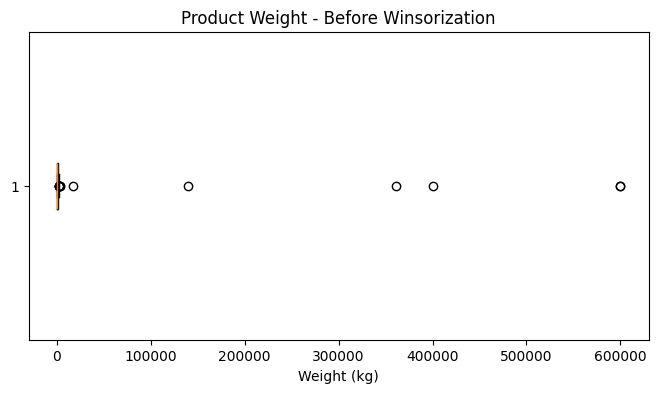

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.boxplot(X_train["Product_Weight"], vert=False)
plt.title("Product Weight - Before Winsorization")
plt.xlabel("Weight (kg)")
plt.show()

In [ ]:
Q1 = X_train["Product_Weight"].quantile(0.25)
Q3 = X_train["Product_Weight"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Lower Bound : {lower:.3f}")
print(f"Upper Bound : {upper:.3f}")

Lower Bound : -1497.500
Upper Bound : 2498.500


In [ ]:
outliers = X_train[
    (X_train["Product_Weight"] < lower) |
    (X_train["Product_Weight"] > upper)
]

print("Number of outliers:", len(outliers))

Number of outliers: 12


In [ ]:
#Step 4.3: Apply Winsorization
X_train["Product_Weight"] = X_train["Product_Weight"].clip(
    lower=lower,
    upper=upper
)

X_test["Product_Weight"] = X_test["Product_Weight"].clip(
    lower=lower,
    upper=upper
)

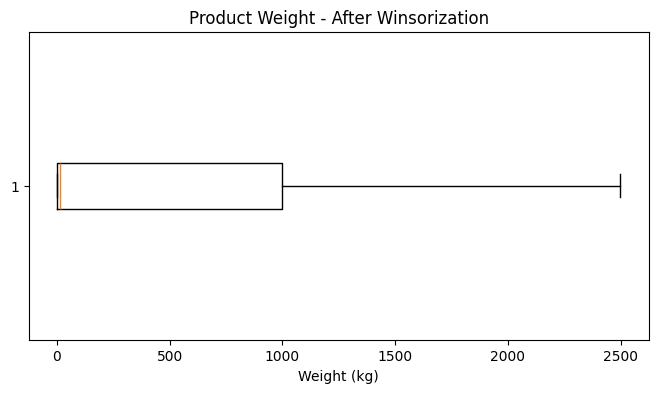

In [ ]:
plt.figure(figsize=(8,4))
plt.boxplot(X_train["Product_Weight"], vert=False)
plt.title("Product Weight - After Winsorization")
plt.xlabel("Weight (kg)")
plt.show()

In [ ]:
X_train["Product_Weight"].describe()

,Product_Weight
count,692.000000
mean,363.167180
std,601.179966
min,0.002000
25%,1.000000
50%,15.807694
75%,1000.000000
max,2498.500000


#### Encoding start

In [ ]:
X_train["Stage_Level_CO2e_Available"].value_counts()

,count
Stage_Level_CO2e_Available,
No,370
Yes,322


In [ ]:
binary_map = {
    "No": 0,
    "Yes": 1
}

X_train["Stage_Level_CO2e_Available"] = (
    X_train["Stage_Level_CO2e_Available"]
    .map(binary_map)
)

X_test["Stage_Level_CO2e_Available"] = (
    X_test["Stage_Level_CO2e_Available"]
    .map(binary_map)
)

In [ ]:
X_train["Stage_Level_CO2e_Available"].value_counts()

,count
Stage_Level_CO2e_Available,
0,370
1,322


In [ ]:
pip install TargetEncoder

ERROR: Could not find a version that satisfies the requirement TargetEncoder (from versions: none)
ERROR: No matching distribution found for TargetEncoder


In [ ]:
import sys
!{sys.executable} -m pip install category_encoders

# Step 5.2: Target Encoding (Company)
from category_encoders import TargetEncoder

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 4.5 MB/s eta 0:00:00


In [ ]:
te = TargetEncoder(
    cols=["Company"],
    min_samples_leaf=20,
    smoothing=10
)

X_train = te.fit_transform(X_train, y_train)

X_test = te.transform(X_test)

In [ ]:
X_train.head()

,Year,Company,Stage_Level_CO2e_Available,Industry,Product_Weight,PCF_Protocol,Region
818,2015,15951.431092,1,Not used for 2015 reporting,6.4,Not reported,Europe
558,2014,15075.895807,0,Chemicals,1.0,Not reported,Europe
428,2014,15968.350188,1,Paper & Forest Products,1000.0,GHGP,South America
7,2013,16489.317365,0,Other,1000.0,Not reported,Europe
506,2016,10365.445532,0,Household Durables,99.5,TRACI 2.1,North America


In [ ]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Industry",
    "PCF_Protocol",
    "Region"
]

encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

encoded_train = encoder.fit_transform(
    X_train[categorical_features]
)

encoded_test = encoder.transform(
    X_test[categorical_features]
)

In [ ]:
encoded_train_df = pd.DataFrame(
    encoded_train,
    columns=encoder.get_feature_names_out(categorical_features),
    index=X_train.index
)

encoded_test_df = pd.DataFrame(
    encoded_test,
    columns=encoder.get_feature_names_out(categorical_features),
    index=X_test.index
)

In [ ]:
X_train = pd.concat(
    [
        X_train.drop(columns=categorical_features),
        encoded_train_df
    ],
    axis=1
)

X_test = pd.concat(
    [
        X_test.drop(columns=categorical_features),
        encoded_test_df
    ],
    axis=1
)

In [ ]:
print(X_train.shape)
print(X_test.shape)



(692, 34)
(174, 34)


In [ ]:
X_train.head()

,Year,Company,Stage_Level_CO2e_Available,Product_Weight,Industry_Automobiles,Industry_Beverages,Industry_Chemicals,Industry_Commercial Services & Supplies,Industry_Computers & Peripherals,Industry_Containers & Packaging,...,PCF_Protocol_Other,PCF_Protocol_PAS2050,PCF_Protocol_TRACI 2.1,Region_East Asia,Region_Europe,Region_North America,Region_Oceania,Region_South America,Region_South Asia,Region_Southeast Asia
818,2015,15951.431092,1,6.4,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
558,2014,15075.895807,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
428,2014,15968.350188,1,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7,2013,16489.317365,0,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
506,2016,10365.445532,0,99.5,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
X_test.head()

,Year,Company,Stage_Level_CO2e_Available,Product_Weight,Industry_Automobiles,Industry_Beverages,Industry_Chemicals,Industry_Commercial Services & Supplies,Industry_Computers & Peripherals,Industry_Containers & Packaging,...,PCF_Protocol_Other,PCF_Protocol_PAS2050,PCF_Protocol_TRACI 2.1,Region_East Asia,Region_Europe,Region_North America,Region_Oceania,Region_South America,Region_South Asia,Region_Southeast Asia
823,2017,14134.466016,1,26.000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
483,2013,14615.861638,1,11.200,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
651,2017,9476.191838,1,20.000,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
811,2016,15968.950368,0,1000.000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
23,2015,9402.086088,0,0.997,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 692 entries, 818 to 102
Data columns (total 34 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Year                                                     692 non-null    int64  
 1   Company                                                  692 non-null    float64
 2   Stage_Level_CO2e_Available                               692 non-null    int64  
 3   Product_Weight                                           692 non-null    float64
 4   Industry_Automobiles                                     692 non-null    float64
 5   Industry_Beverages                                       692 non-null    float64
 6   Industry_Chemicals                                       692 non-null    float64
 7   Industry_Commercial Services & Supplies                  692 non-null    float64
 8   Industry_Computers & Peripherals 

```
##### Step 6: Scaling
This is the only preprocessing step left before training.
Not every feature should be scaled.

##### Scale these:

* `Year`
* `Company` (target-encoded numeric values)
* `Product_Weight`

##### Do **not** scale:

* `Stage_Level_CO2e_Available`
* One-hot encoded columns (`Industry_*`, `Region_*`, `PCF_Protocol_*`)

Those are binary indicators (0/1), and scaling them generally isn't necessary.

#####  My recommendation

Create **two versions** of your data.

##### Version 1 (Scaled)

Use for:
* Linear Regression
* Ridge Regression
* Lasso Regression
* SVR
* KNN (if you decide to try it)

##### Version 2 (Not Scaled)

Use for:
* Decision Tree
* Random Forest
* XGBoost
* LightGBM
* CatBoost
Tree-based models don't need feature scaling.
```

In [ ]:
X_train

,Year,Company,Stage_Level_CO2e_Available,Product_Weight,Industry_Automobiles,Industry_Beverages,Industry_Chemicals,Industry_Commercial Services & Supplies,Industry_Computers & Peripherals,Industry_Containers & Packaging,...,PCF_Protocol_Other,PCF_Protocol_PAS2050,PCF_Protocol_TRACI 2.1,Region_East Asia,Region_Europe,Region_North America,Region_Oceania,Region_South America,Region_South Asia,Region_Southeast Asia
818,2015,15951.431092,1,6.400000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
558,2014,15075.895807,0,1.000000,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
428,2014,15968.350188,1,1000.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7,2013,16489.317365,0,1000.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
506,2016,10365.445532,0,99.500000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,2015,16502.460181,0,0.816000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
270,2015,13974.042458,0,1000.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
860,2013,15637.589719,1,0.408233,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
435,2015,8838.429485,1,1000.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
import numpy as np

In [ ]:
# =====================================================
# Target Transformation
# =====================================================

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [ ]:
# =====================================================
# Feature Scaling
# =====================================================

from sklearn.preprocessing import StandardScaler

numeric_features = [
    "Company",
    "Product_Weight"
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

X_test_scaled[numeric_features] = scaler.transform(
    X_test[numeric_features]
)

In [ ]:
# =====================================================
# Model Performance Table
# =====================================================

results = pd.DataFrame(
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2_Original",
        "R2_Log"
    ]
)

In [ ]:
# =====================================================
# Model 1 : Linear Regression
# =====================================================

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
# Initialize model
lr = LinearRegression()

# Train using log-transformed target
lr.fit(
    X_train_scaled,
    y_train_log
)

LinearRegression()

In [ ]:
# Prediction on log scale
y_pred_log = lr.predict(
    X_test_scaled
)

# Convert predictions back to original PCF scale
y_pred = np.expm1(
    y_pred_log
)

In [ ]:
# Original scale metrics

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2_original = r2_score(
    y_test,
    y_pred
)

# Log-scale R²

r2_log = r2_score(
    y_test_log,
    y_pred_log
)

In [ ]:
print("=" * 60)
print("Linear Regression (Baseline)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:,.2f}")
print(f"RMSE (Original Scale)      : {rmse:,.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

Linear Regression (Baseline)
MAE (Original Scale)       : 26,910.97
RMSE (Original Scale)      : 298,528.55
R² (Original Scale)        : -586.3506
R² (Log-transformed Scale) : 0.6335
